In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parents[0]
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from ripser import ripser
from persim import plot_diagrams

from tomato.tda import witness_dm
from tomato.persistence_analysis import (
    PersistenceAnalyzer,
    PersistenceLandscape,
    BettiCurve,
    compute_persistence_statistics,
    DiagramDistance
)

In [ ]:
# Load the data from CSV
csv_path = project_root / 'data' / 'rotten_tomatoes_movies.csv'
df_movies = pd.read_csv(csv_path)

print(f"Total number of movies: {len(df_movies)}")
df_movies.head()

Total number of movies: 17712


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3


Number of movies after cleaning: 17173


/var/folders/kg/sv90sjqx3gg_69mdr6c3262m0000gn/T/ipykernel_21515/3484329561.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['genre_list'] = df_clean['genres'].apply(parse_genres)


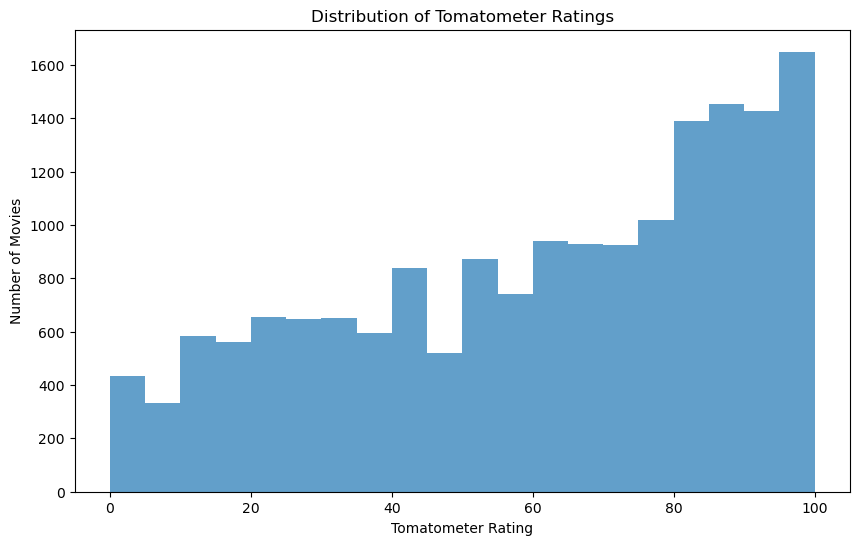


Top 10 Genres:
Drama                        9351
Comedy                       5502
Action & Adventure           3494
Mystery & Suspense           3482
Art House & International    2437
Horror                       2001
Documentary                  1914
Romance                      1889
Science Fiction & Fantasy    1826
Classics                     1644
Name: count, dtype: int64


In [ ]:
df_movies['tomatometer_rating'] = pd.to_numeric(df_movies['tomatometer_rating'], errors='coerce')
df_movies['audience_rating'] = pd.to_numeric(df_movies['audience_rating'], errors='coerce')

df_clean = df_movies.dropna(subset=['movie_info', 'tomatometer_rating', 'audience_rating'])

print(f"Number of movies after cleaning: {len(df_clean)}")

def parse_genres(genre_str):
    if pd.isna(genre_str):
        return []
    return [g.strip() for g in genre_str.split(',')]
df_clean['genre_list'] = df_clean['genres'].apply(parse_genres)

plt.figure(figsize=(10, 6))
plt.hist(df_clean['tomatometer_rating'], bins=20, alpha=0.7)
plt.title('Distribution of Tomatometer Ratings')
plt.xlabel('Tomatometer Rating')
plt.ylabel('Number of Movies')
plt.show()

all_genres = [genre for genres in df_clean['genre_list'] for genre in genres]
genre_counts = pd.Series(all_genres).value_counts().head(10)
print("\nTop 10 Genres:")
print(genre_counts)

In [4]:
# Create TF-IDF vectors from movie descriptions
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
movie_vectors = tfidf.fit_transform(df_clean['movie_info'])

print(f"Feature vector shape: {movie_vectors.shape}")
print(f"Top features: {tfidf.get_feature_names_out()[:10]}")

Feature vector shape: (17173, 500)
Top features: ['accident' 'act' 'action' 'actor' 'actress' 'adam' 'adventure' 'affair'
 'age' 'agent']


In [ ]:
def get_rating_group(rating):
    if rating < 40:
        return 'low'
    elif rating < 75:
        return 'medium'
    else:
        return 'high'
    
df_clean['rating_group'] = df_clean['tomatometer_rating'].apply(get_rating_group)

rating_counts = df_clean['rating_group'].value_counts()
print("Movies per rating group:")
print(rating_counts)

sample_size = min(500, rating_counts.min())
print(f"\nSampling {sample_size} movies from each rating group")

groups = {}
for group in ['low', 'medium', 'high']:
    group_df = df_clean[df_clean['rating_group'] == group].sample(sample_size, random_state=42)
    groups[group] = group_df
    print(f"{group} group: {len(group_df)} movies")

Movies per rating group:
rating_group
high      6941
medium    5770
low       4462
Name: count, dtype: int64

Sampling 500 movies from each rating group
low group: 500 movies
medium group: 500 movies
high group: 500 movies


/var/folders/kg/sv90sjqx3gg_69mdr6c3262m0000gn/T/ipykernel_21515/594224600.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['rating_group'] = df_clean['tomatometer_rating'].apply(get_rating_group)


In [ ]:
def create_distance_matrix(group_df):
    # Get the TF-IDF vectors for the group
    # We need to map dataframe indices to positions in the movie_vectors matrix
    # Create a mapping from the original indices to row positions in movie_vectors
    index_map = {idx: i for i, idx in enumerate(df_clean.index)}
    
    positions = [index_map[idx] for idx in group_df.index]
    group_vectors = movie_vectors[positions]
    
    distances = cosine_distances(group_vectors)
    
    return distances

distance_matrices = {}
for group_name, group_df in groups.items():
    distance_matrices[group_name] = create_distance_matrix(group_df)
    print(f"{group_name} distance matrix shape: {distance_matrices[group_name].shape}")

low distance matrix shape: (500, 500)
medium distance matrix shape: (500, 500)
high distance matrix shape: (500, 500)


In [ ]:
analyzer = PersistenceAnalyzer(max_homology_dim=2)

ripser_diagrams = analyzer.compute_persistence_diagrams(
    distance_matrices, 
    method="ripser",
    thresh=0.5
)

witness_diagrams = analyzer.compute_persistence_diagrams(
    distance_matrices, 
    method="witness",
    k=min(30, sample_size // 2),
    alpha2=0.2,
    seed=42
)

/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/visuals.py:155: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim([x_down, x_up])
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/visuals.py:156: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([y_down, y_up])


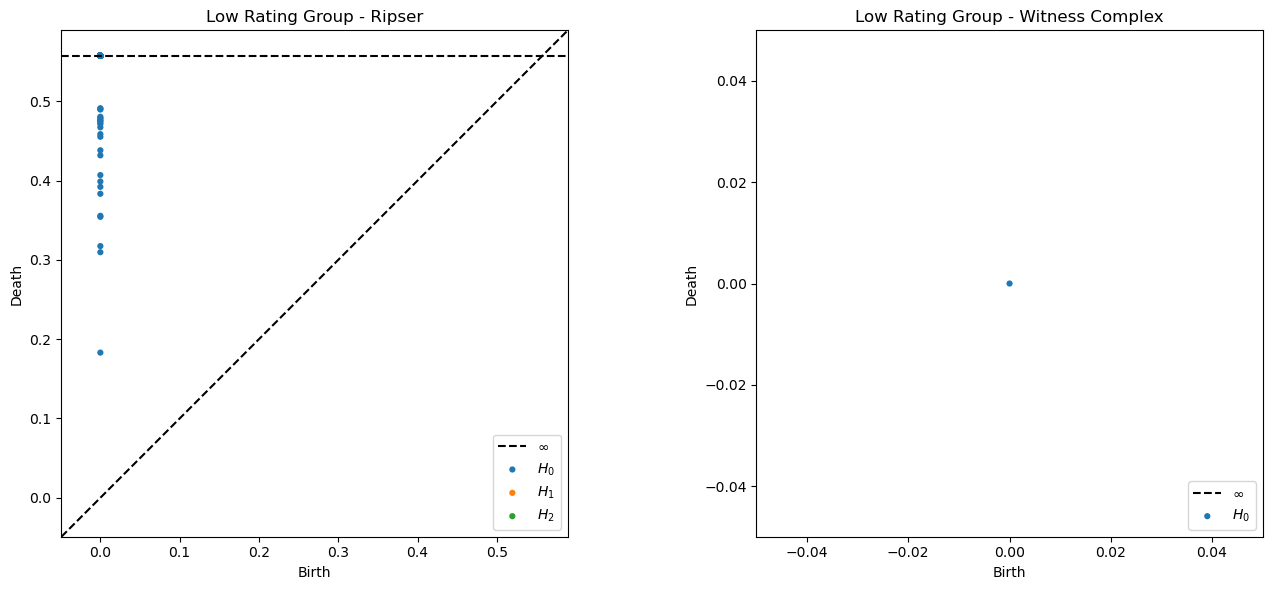

/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/visuals.py:155: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim([x_down, x_up])
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/visuals.py:156: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([y_down, y_up])


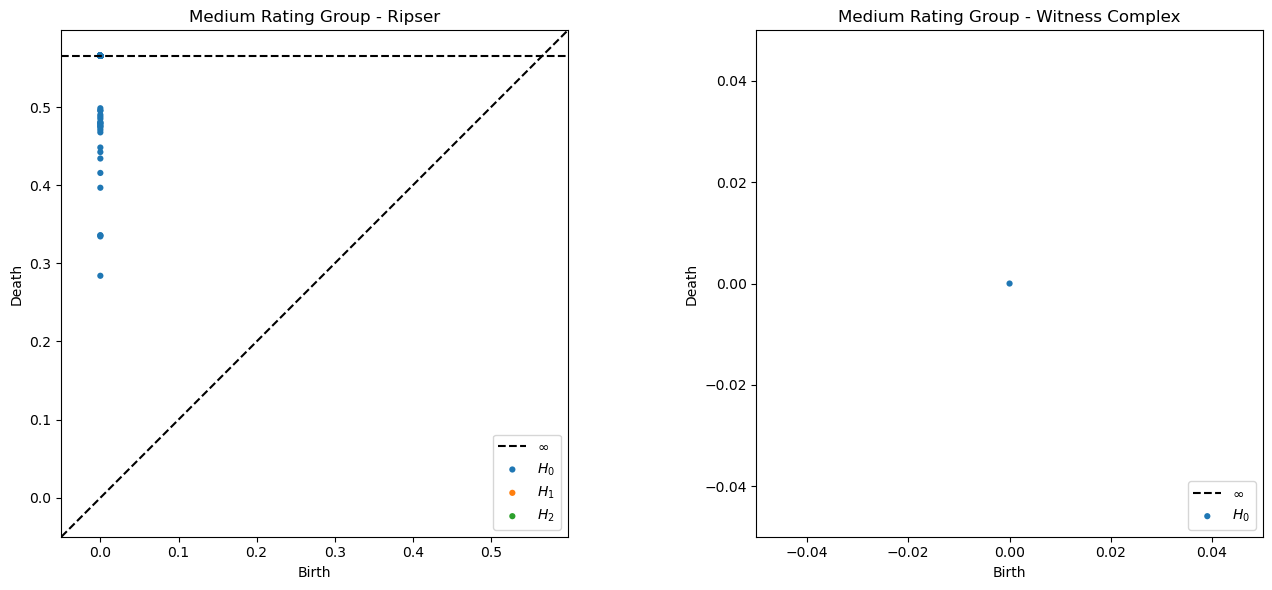

/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/visuals.py:155: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim([x_down, x_up])
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/visuals.py:156: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([y_down, y_up])


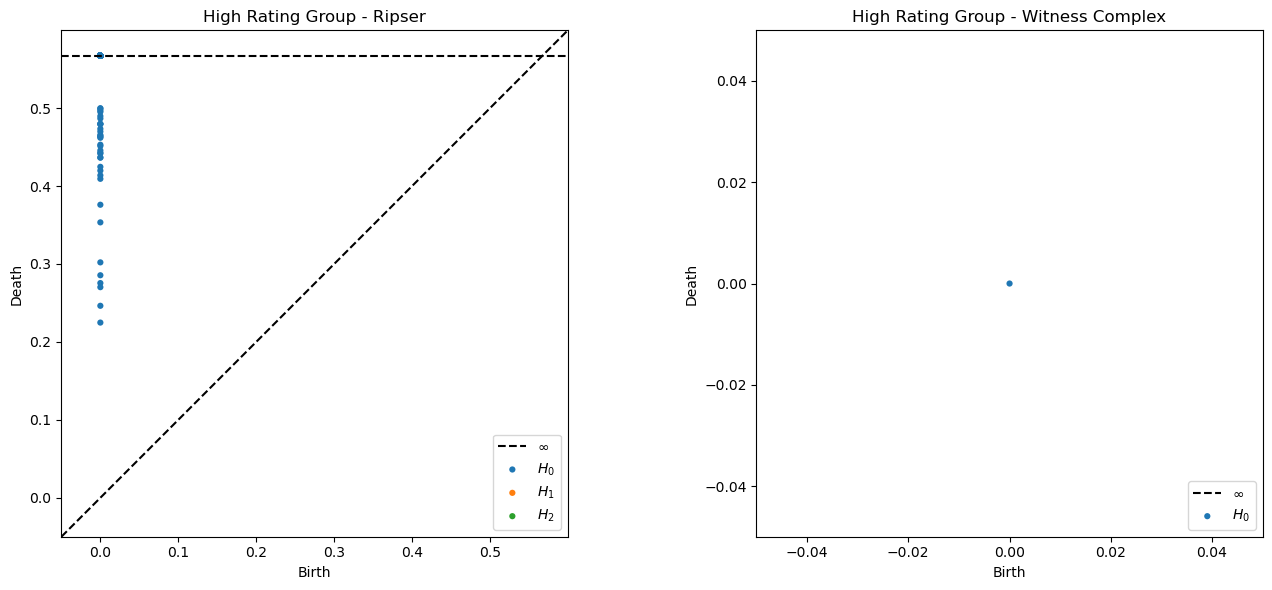

In [ ]:
for group_name in distance_matrices.keys():
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    plot_diagrams(ripser_diagrams[group_name], ax=axs[0])
    axs[0].set_title(f"{group_name.capitalize()} Rating Group - Ripser")
    
    plot_diagrams(witness_diagrams[group_name], ax=axs[1])
    axs[1].set_title(f"{group_name.capitalize()} Rating Group - Witness Complex")
    
    plt.tight_layout()
    plt.show()

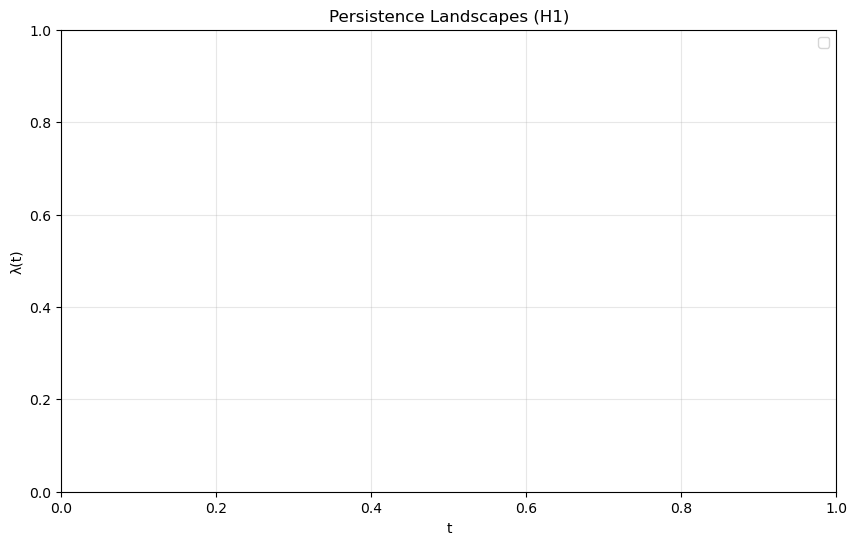

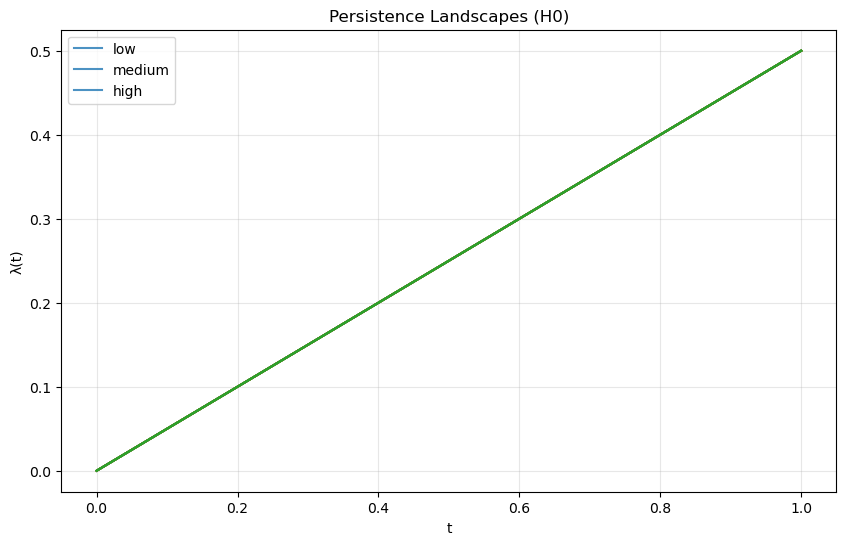

In [ ]:
analyzer.diagrams = ripser_diagrams

landscapes = analyzer.compute_all_landscapes(num_landscapes=5, resolution=200, domain=(0, 0.5))

fig = analyzer.plot_landscapes(homology_dim=1, figsize=(10, 6))
plt.show()

fig = analyzer.plot_landscapes(homology_dim=0, figsize=(10, 6))
plt.show()

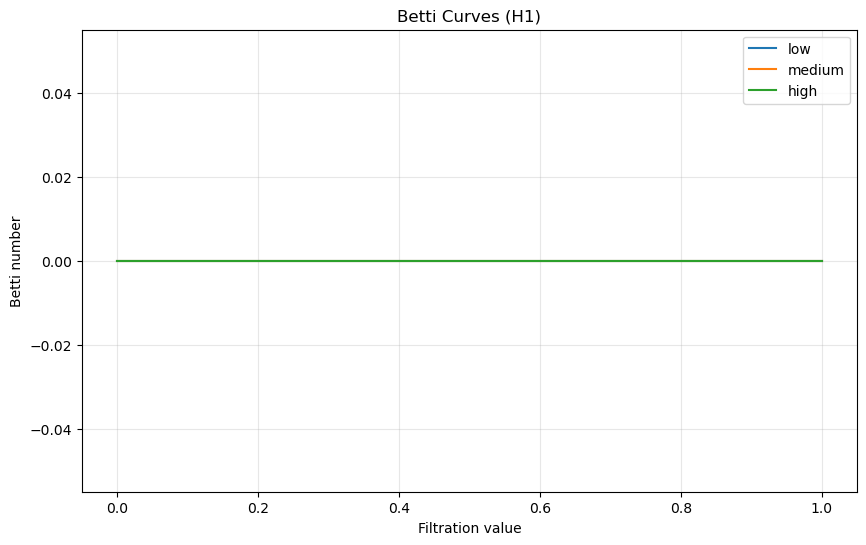

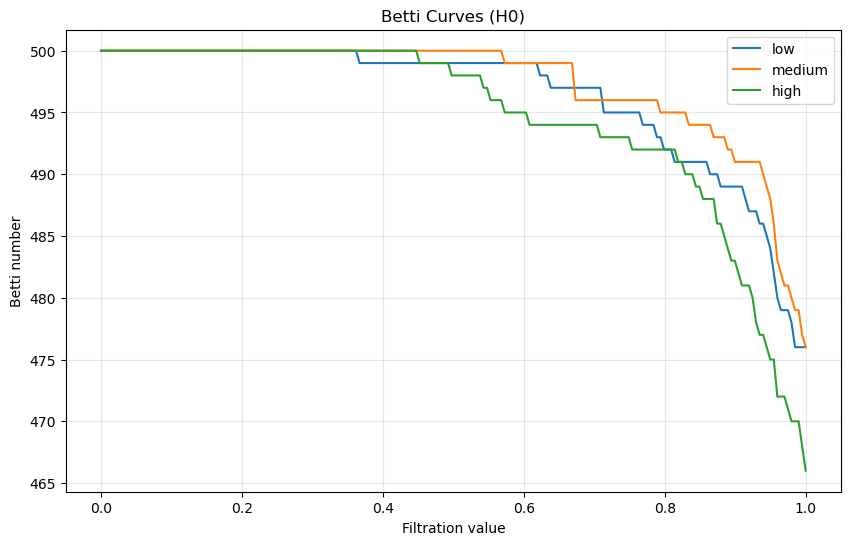

In [ ]:
betti_curves = analyzer.compute_all_betti_curves(resolution=200, domain=(0, 0.5))

fig = analyzer.plot_betti_curves(homology_dim=1, figsize=(10, 6))
plt.show()

fig = analyzer.plot_betti_curves(homology_dim=0, figsize=(10, 6))
plt.show()


Statistics for low:
  dim0_num_features: 500
  dim0_total_persistence: inf
  dim0_max_persistence: inf
  dim0_mean_persistence: inf
  dim0_median_persistence: inf
  dim0_std_persistence: nan
  total_persistence: inf
  max_persistence: inf
  mean_persistence: inf
  median_persistence: inf
  std_persistence: nan

Statistics for medium:
  dim0_num_features: 500
  dim0_total_persistence: inf
  dim0_max_persistence: inf
  dim0_mean_persistence: inf
  dim0_median_persistence: inf
  dim0_std_persistence: nan
  total_persistence: inf
  max_persistence: inf
  mean_persistence: inf
  median_persistence: inf
  std_persistence: nan

Statistics for high:
  dim0_num_features: 500
  dim0_total_persistence: inf
  dim0_max_persistence: inf
  dim0_mean_persistence: inf
  dim0_median_persistence: inf
  dim0_std_persistence: nan
  total_persistence: inf
  max_persistence: inf
  mean_persistence: inf
  median_persistence: inf
  std_persistence: nan


/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,total_persistence,max_persistence,mean_persistence,dim0_features,dim1_features
low,inf,inf,inf,500.0,0.0
medium,inf,inf,inf,500.0,0.0
high,inf,inf,inf,500.0,0.0


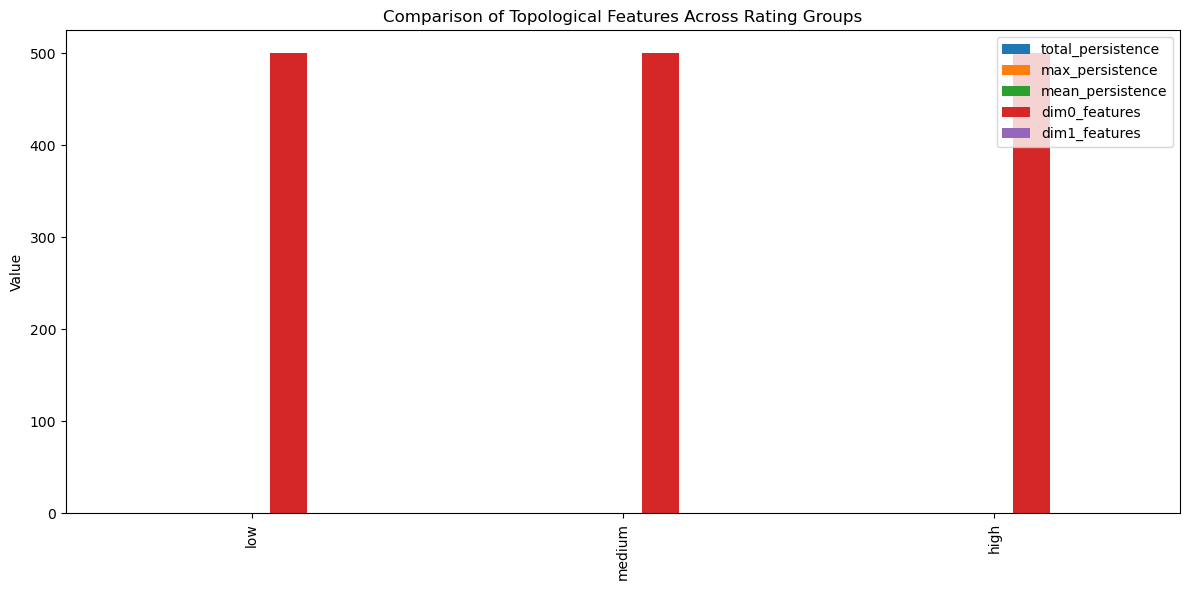

In [ ]:
stats = analyzer.compute_all_statistics()

for group_name, group_stats in stats.items():
    print(f"\nStatistics for {group_name}:")
    for stat_name, stat_value in group_stats.items():
        print(f"  {stat_name}: {stat_value}")
        
comparison_stats = {}
for group_name, group_stats in stats.items():
    comparison_stats[group_name] = {
        'total_persistence': group_stats.get('total_persistence', 0),
        'max_persistence': group_stats.get('max_persistence', 0),
        'mean_persistence': group_stats.get('mean_persistence', 0),
        'dim0_features': group_stats.get('dim0_num_features', 0),
        'dim1_features': group_stats.get('dim1_num_features', 0)
    }
    
df_comparison = pd.DataFrame(comparison_stats).T
display(df_comparison)

df_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Topological Features Across Rating Groups')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


Wasserstein distances between groups:


/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/wasserstein.py:51: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/wasserstein.py:61: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/wasserstein.py:51: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/wasserstein.py:61: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/wasserstein.py:51: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/wasserstein.py:61: UserWarnin

,low,medium,high
low,0.0,0.0,0.0
medium,0.0,0.0,0.0
high,0.0,0.0,0.0



Bottleneck distances between groups:


/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/persim/bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(


,low,medium,high
low,0.000000,0.100992,0.209884
medium,0.100992,0.000000,0.206838
high,0.209884,0.206838,0.000000


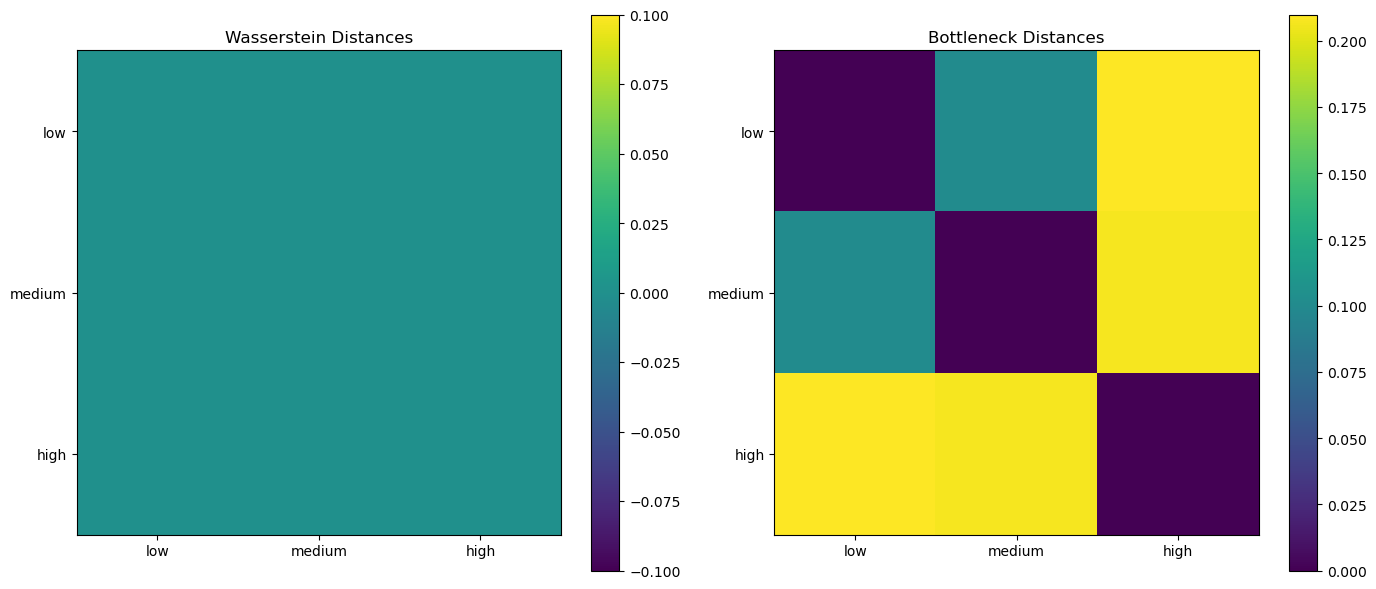

In [ ]:
wasserstein_distances = analyzer.compare_groups(metric="wasserstein", p=2)
print("\nWasserstein distances between groups:")
display(wasserstein_distances)

bottleneck_distances = analyzer.compare_groups(metric="bottleneck")
print("\nBottleneck distances between groups:")
display(bottleneck_distances)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

im0 = axs[0].imshow(wasserstein_distances.values, cmap='viridis')
axs[0].set_title('Wasserstein Distances')
axs[0].set_xticks(np.arange(len(wasserstein_distances.columns)))
axs[0].set_yticks(np.arange(len(wasserstein_distances.index)))
axs[0].set_xticklabels(wasserstein_distances.columns)
axs[0].set_yticklabels(wasserstein_distances.index)
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(bottleneck_distances.values, cmap='viridis')
axs[1].set_title('Bottleneck Distances')
axs[1].set_xticks(np.arange(len(bottleneck_distances.columns)))
axs[1].set_yticks(np.arange(len(bottleneck_distances.index)))
axs[1].set_xticklabels(bottleneck_distances.columns)
axs[1].set_yticklabels(bottleneck_distances.index)
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()

Analyzing genres: Index(['Drama', 'Comedy', 'Action & Adventure'], dtype='object')
Drama group: 500 movies, distance matrix shape: (500, 500)
Comedy group: 500 movies, distance matrix shape: (500, 500)
Action & Adventure group: 500 movies, distance matrix shape: (500, 500)


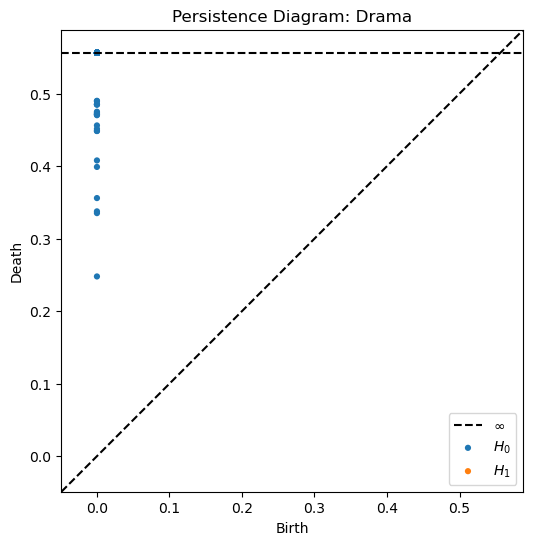

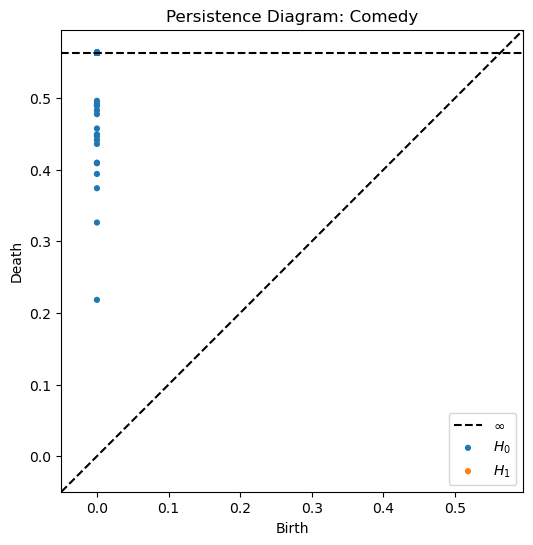

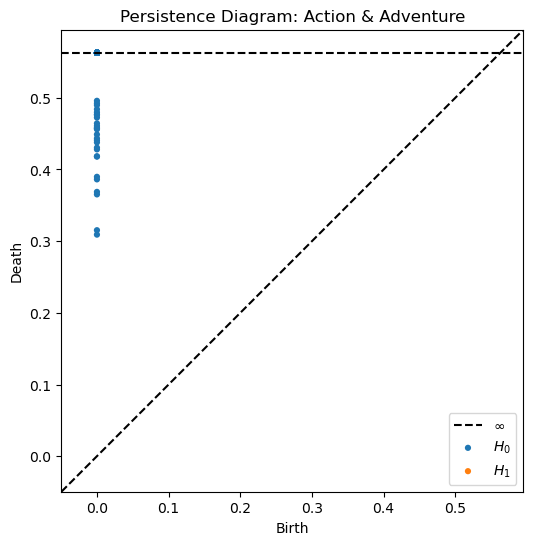

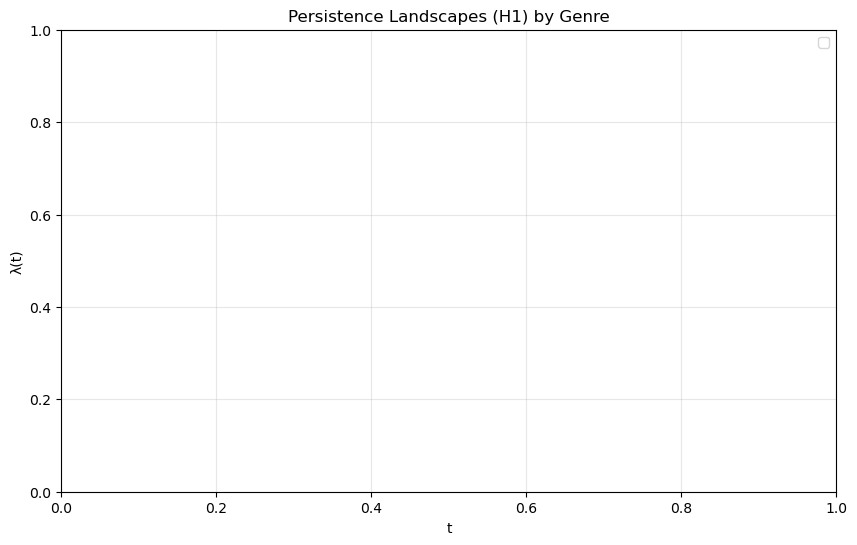

/Users/lianghaochen/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,total_persistence,max_persistence,mean_persistence,dim0_features,dim1_features
Drama,inf,inf,inf,500.0,0.0
Comedy,inf,inf,inf,499.0,0.0
Action & Adventure,inf,inf,inf,500.0,0.0


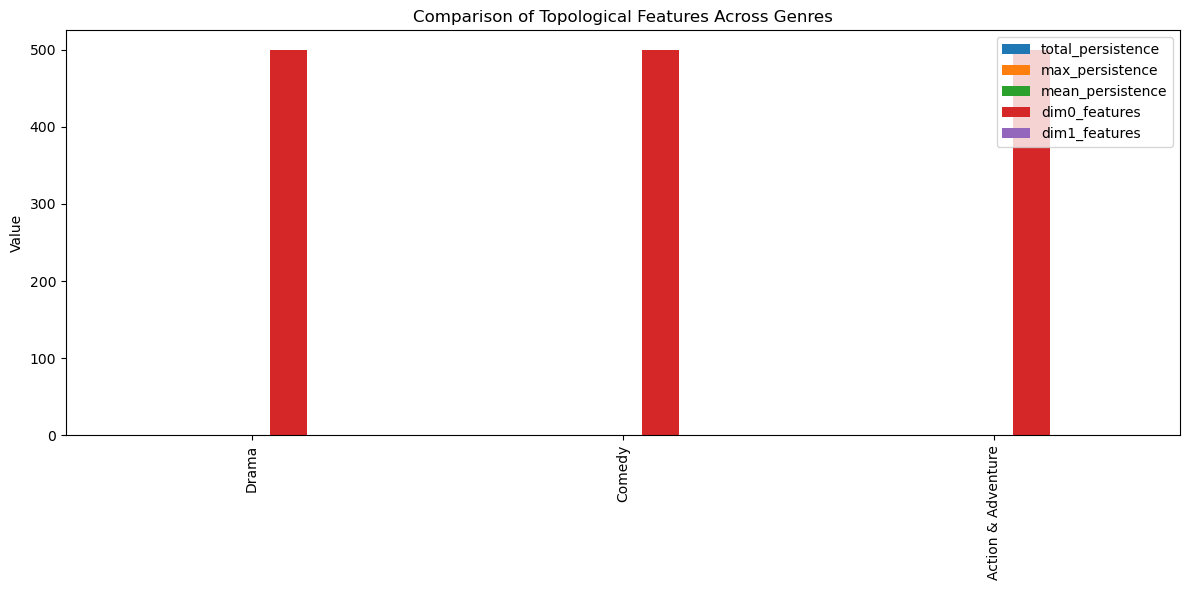

In [ ]:
common_genres = genre_counts.index[:3]
print(f"Analyzing genres: {common_genres}")

genre_groups = {}
genre_dfs = {}

for genre in common_genres:
    genre_movies = df_clean[df_clean['genre_list'].apply(lambda x: genre in x)]
    genre_sample = genre_movies.sample(min(sample_size, len(genre_movies)), random_state=42)
    genre_dfs[genre] = genre_sample
    genre_groups[genre] = create_distance_matrix(genre_sample)
    print(f"{genre} group: {len(genre_sample)} movies, distance matrix shape: {genre_groups[genre].shape}")

genre_analyzer = PersistenceAnalyzer(max_homology_dim=1)
genre_diagrams = genre_analyzer.compute_persistence_diagrams(
    genre_groups, 
    method="ripser",
    thresh=0.5
)

for genre in common_genres:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_diagrams(genre_diagrams[genre], ax=ax)
    ax.set_title(f"Persistence Diagram: {genre}")
    plt.show()

genre_analyzer.diagrams = genre_diagrams
genre_landscapes = genre_analyzer.compute_all_landscapes()
fig = genre_analyzer.plot_landscapes(homology_dim=1, figsize=(10, 6))
plt.title('Persistence Landscapes (H1) by Genre')
plt.show()

genre_stats = genre_analyzer.compute_all_statistics()

genre_comparison = {}
for genre, stats in genre_stats.items():
    genre_comparison[genre] = {
        'total_persistence': stats.get('total_persistence', 0),
        'max_persistence': stats.get('max_persistence', 0),
        'mean_persistence': stats.get('mean_persistence', 0),
        'dim0_features': stats.get('dim0_num_features', 0),
        'dim1_features': stats.get('dim1_num_features', 0)
    }
    
df_genre_comparison = pd.DataFrame(genre_comparison).T
display(df_genre_comparison)

df_genre_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Topological Features Across Genres')
plt.ylabel('Value')
plt.tight_layout()
plt.show()